# 01 — Data Exploration
**E-Waste Toxic Gas Detection System — ML Pipeline**

**Purpose:** Understand the structure, distribution, and quality of our training datasets before any preprocessing.

**Datasets used:**
- `datasets/collected/lab_readings.csv` — self-collected data
- `datasets/raw/mq_sensor_2023/` — MQ Sensor Mendeley dataset
- Any UCI dataset placed in `datasets/raw/`

**Author:** Sanjula Madushanka | Final Year Research Y4S2

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
FIGSIZE = (14, 6)
SAVE_DIR = Path('../results')
SAVE_DIR.mkdir(exist_ok=True)

print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


## 1.1 Load Dataset

In [2]:
# ============================================================
# LOAD DATA
# ============================================================
DATA_DIR = Path('../datasets')

# Load self-collected data (primary)
collected_path = DATA_DIR / 'collected' / 'lab_readings.csv'

if collected_path.exists():
    df_collected = pd.read_csv(collected_path)
    print(f'✅ Self-collected data loaded: {len(df_collected)} rows')
else:
    # Create a synthetic demonstration dataset with realistic values
    print('⚠ No collected data found — generating DEMO dataset for development')
    print('  → Replace with real data when available')
    
    np.random.seed(42)
    n_per_class = 150
    
    # Realistic sensor profiles per gas class
    # Each row: [mq2, mq7, mq135, mq303, mq136, temp, humidity]
    profiles = {
        'CO':      {'mq2': (30, 15),  'mq7': (80, 25),   'mq135': (10, 5),  'mq303': (0.005, 0.002), 'mq136': (0.3, 0.15)},
        'LPG':     {'mq2': (200, 80), 'mq7': (10, 5),    'mq135': (8, 4),   'mq303': (0.004, 0.002), 'mq136': (0.2, 0.1)},
        'BENZENE': {'mq2': (15, 8),   'mq7': (8, 4),     'mq135': (45, 15), 'mq303': (0.006, 0.003), 'mq136': (0.4, 0.2)},
        'AMMONIA': {'mq2': (12, 6),   'mq7': (6, 3),     'mq135': (60, 20), 'mq303': (0.004, 0.002), 'mq136': (0.3, 0.15)},
        'MERCURY': {'mq2': (8, 4),    'mq7': (5, 2.5),   'mq135': (6, 3),   'mq303': (0.05, 0.02),  'mq136': (0.2, 0.1)},
        'H2S':     {'mq2': (10, 5),   'mq7': (7, 3.5),   'mq135': (9, 4.5), 'mq303': (0.005, 0.002), 'mq136': (3.5, 1.2)},
        'CLEAN':   {'mq2': (3, 1.5),  'mq7': (2, 1),     'mq135': (3, 1.5), 'mq303': (0.001, 0.0005),'mq136': (0.1, 0.05)},
    }
    
    rows = []
    for label, p in profiles.items():
        for _ in range(n_per_class):
            rows.append({
                'mq2_ppm':   max(0, np.random.normal(*p['mq2'])),
                'mq7_ppm':   max(0, np.random.normal(*p['mq7'])),
                'mq135_ppm': max(0, np.random.normal(*p['mq135'])),
                'mq303_ppm': max(0, np.random.normal(*p['mq303'])),
                'mq136_ppm': max(0, np.random.normal(*p['mq136'])),
                'temperature_c': np.random.normal(28, 3),
                'humidity_pct':  np.clip(np.random.normal(65, 10), 30, 95),
                'gas_class': label
            })
    
    df_collected = pd.DataFrame(rows)
    # Save demo dataset
    collected_path.parent.mkdir(parents=True, exist_ok=True)
    df_collected.to_csv(collected_path, index=False)
    print(f'  Demo dataset saved to {collected_path}')

df = df_collected.copy()
print(f'\nDataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

⚠ No collected data found — generating DEMO dataset for development
  → Replace with real data when available
  Demo dataset saved to ..\datasets\collected\lab_readings.csv

Dataset shape: (1050, 8)
Columns: ['mq2_ppm', 'mq7_ppm', 'mq135_ppm', 'mq303_ppm', 'mq136_ppm', 'temperature_c', 'humidity_pct', 'gas_class']


## 1.2 Basic Information

In [3]:
print('=== DATASET INFO ===')
print(df.info())
print('\n=== FIRST 5 ROWS ===')
df.head()

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   mq2_ppm        1050 non-null   float64
 1   mq7_ppm        1050 non-null   float64
 2   mq135_ppm      1050 non-null   float64
 3   mq303_ppm      1050 non-null   float64
 4   mq136_ppm      1050 non-null   float64
 5   temperature_c  1050 non-null   float64
 6   humidity_pct   1050 non-null   float64
 7   gas_class      1050 non-null   object 
dtypes: float64(7), object(1)
memory usage: 65.8+ KB
None

=== FIRST 5 ROWS ===


,mq2_ppm,mq7_ppm,mq135_ppm,mq303_ppm,mq136_ppm,temperature_c,humidity_pct,gas_class
0,37.450712,76.543392,13.238443,0.008046,0.264877,27.297589,80.792128,CO
1,41.511521,68.263140,12.712800,0.004073,0.230141,28.725887,45.867198,CO
2,4.126233,65.942812,4.935844,0.005628,0.163796,23.763089,79.656488,CO
3,26.613355,81.688205,2.876259,0.003911,0.316638,24.547019,68.756980,CO
4,20.990420,72.707656,6.991467,0.008705,0.297975,24.826867,73.225449,CO


In [4]:
print('=== STATISTICAL SUMMARY ===')
df.describe().round(4)

=== STATISTICAL SUMMARY ===


,mq2_ppm,mq7_ppm,mq135_ppm,mq303_ppm,mq136_ppm,temperature_c,humidity_pct
count,1050.0000,1050.0000,1050.0000,1050.0000,1050.0000,1050.0000,1050.0000
mean,40.7441,17.0350,20.0173,0.0104,0.6930,28.1477,65.1450
std,74.0672,28.1309,22.7398,0.0173,1.1902,2.9983,9.7709
min,0.0000,0.0000,0.0000,0.0000,0.0000,18.4699,36.0049
25%,5.5253,3.2397,4.9656,0.0024,0.1366,26.1174,58.4842
50%,11.8688,6.6839,9.3345,0.0047,0.2502,28.2795,65.1591
75%,26.3072,11.4435,28.8613,0.0071,0.4585,30.1336,71.5731
max,404.6559,141.5811,103.3987,0.1051,6.0264,37.5793,95.0000


## 1.3 Missing Value Analysis

In [5]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('=== MISSING VALUES ===')
print(missing_df)

if missing.sum() == 0:
    print('\n✅ No missing values found!')
else:
    print(f'\n⚠ Total missing values: {missing.sum()} — will handle in preprocessing notebook')

=== MISSING VALUES ===
               Missing Count  Missing %
mq2_ppm                    0        0.0
mq7_ppm                    0        0.0
mq135_ppm                  0        0.0
mq303_ppm                  0        0.0
mq136_ppm                  0        0.0
temperature_c              0        0.0
humidity_pct               0        0.0
gas_class                  0        0.0

✅ No missing values found!


## 1.4 Class Distribution

In [6]:
class_col = 'gas_class' if 'gas_class' in df.columns else df.select_dtypes(include='object').columns[0]

class_counts = df[class_col].value_counts()
print('=== CLASS DISTRIBUTION ===')
print(class_counts)
print(f'\nTotal classes: {len(class_counts)}')
print(f'Most common: {class_counts.idxmax()} ({class_counts.max()})')
print(f'Least common: {class_counts.idxmin()} ({class_counts.min()})')
print(f'Imbalance ratio: {class_counts.max() / class_counts.min():.2f}x')

if class_counts.max() / class_counts.min() > 3:
    print('\n⚠ Significant class imbalance detected → Apply SMOTE in preprocessing')
else:
    print('\n✅ Class distribution is reasonably balanced')

=== CLASS DISTRIBUTION ===
gas_class
CO         150
LPG        150
BENZENE    150
AMMONIA    150
MERCURY    150
H2S        150
CLEAN      150
Name: count, dtype: int64

Total classes: 7
Most common: CO (150)
Least common: CO (150)
Imbalance ratio: 1.00x

✅ Class distribution is reasonably balanced


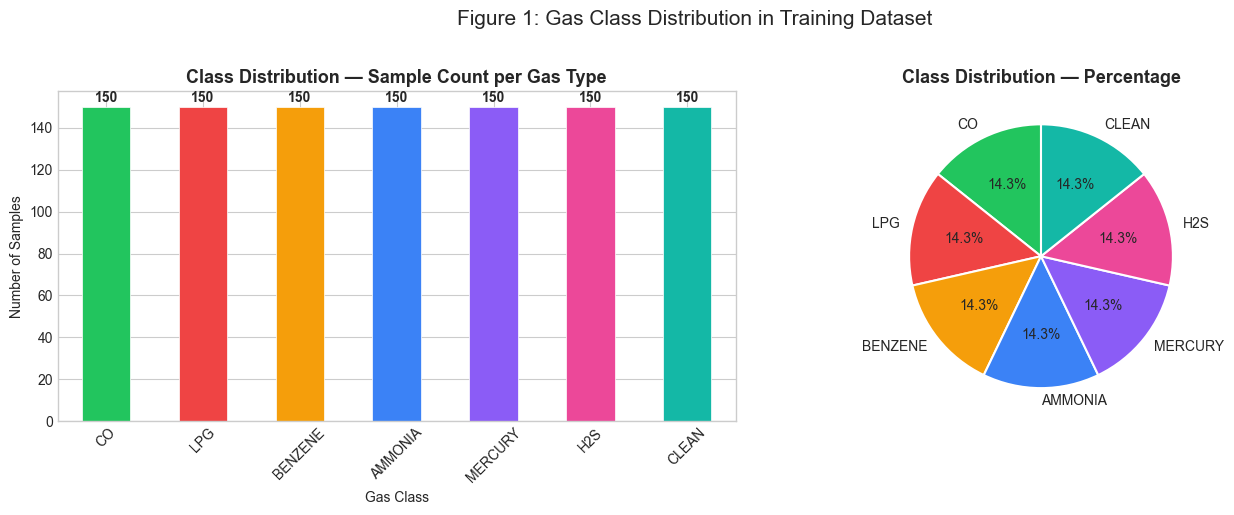

Figure saved ✅


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#22c55e', '#ef4444', '#f59e0b', '#3b82f6', '#8b5cf6', '#ec4899', '#14b8a6']
class_counts.plot(kind='bar', ax=axes[0], color=colors[:len(class_counts)], edgecolor='white', linewidth=0.5)
axes[0].set_title('Class Distribution — Sample Count per Gas Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Gas Class')
axes[0].set_ylabel('Number of Samples')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors[:len(class_counts)], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Class Distribution — Percentage', fontsize=13, fontweight='bold')

plt.suptitle('Figure 1: Gas Class Distribution in Training Dataset', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved ✅')

## 1.5 Feature Distributions

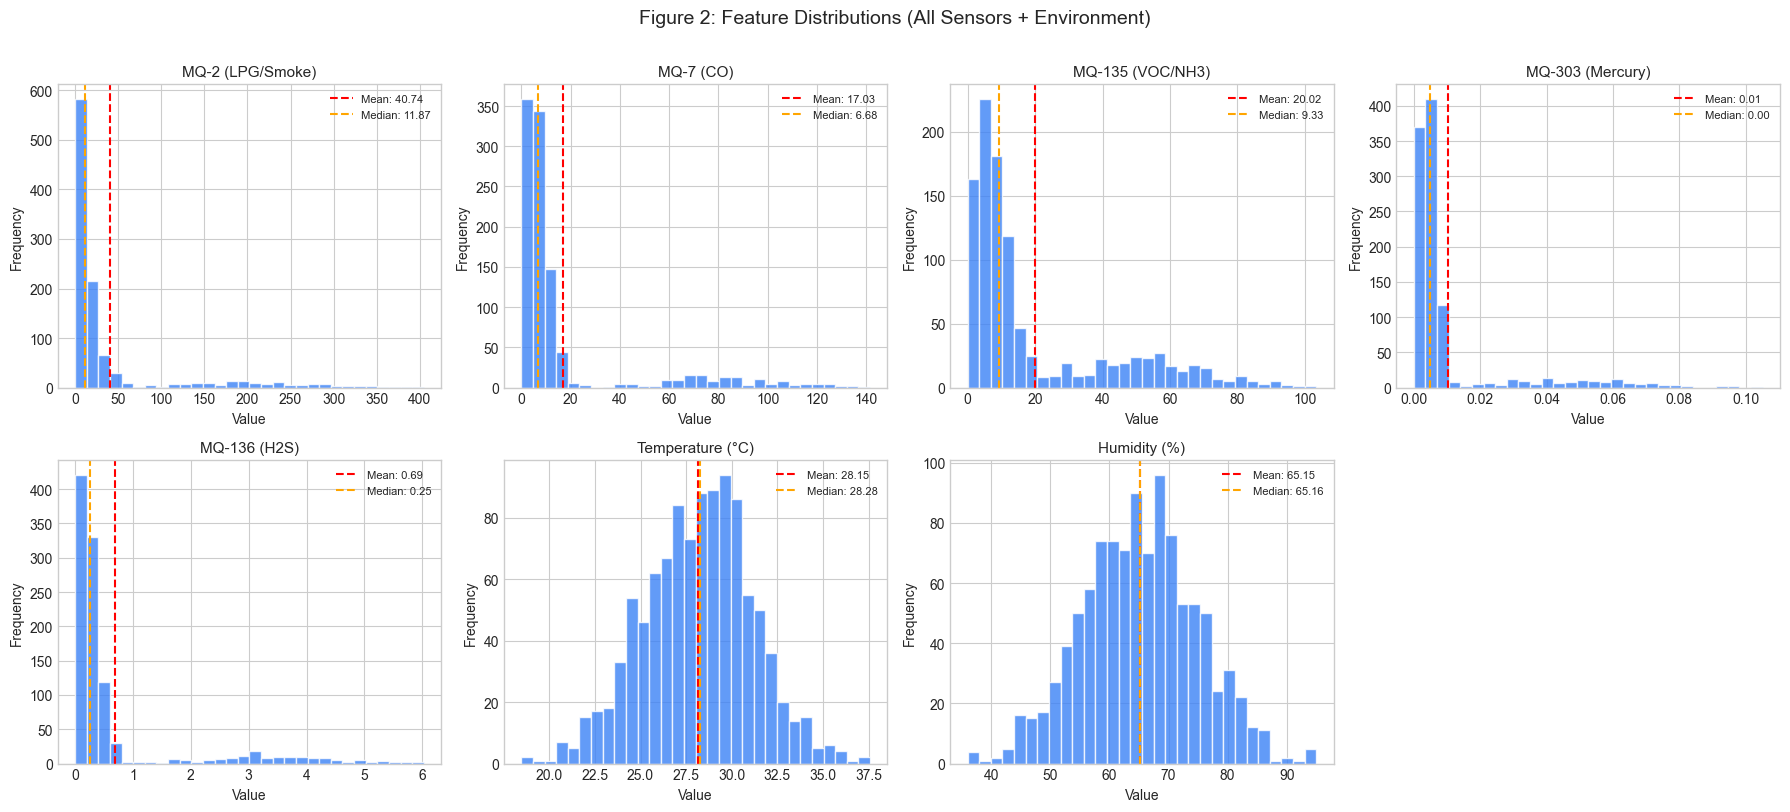

Figure saved ✅


In [8]:
feature_cols = ['mq2_ppm', 'mq7_ppm', 'mq135_ppm', 'mq303_ppm', 'mq136_ppm', 'temperature_c', 'humidity_pct']
feature_cols = [c for c in feature_cols if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

sensor_names = {
    'mq2_ppm':       'MQ-2 (LPG/Smoke)',
    'mq7_ppm':       'MQ-7 (CO)',
    'mq135_ppm':     'MQ-135 (VOC/NH3)',
    'mq303_ppm':     'MQ-303 (Mercury)',
    'mq136_ppm':     'MQ-136 (H2S)',
    'temperature_c': 'Temperature (°C)',
    'humidity_pct':  'Humidity (%)'
}

for i, col in enumerate(feature_cols):
    ax = axes[i]
    ax.hist(df[col], bins=30, color='#3b82f6', edgecolor='white', alpha=0.8)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {df[col].median():.2f}')
    ax.set_title(sensor_names.get(col, col), fontsize=11)
    ax.legend(fontsize=8)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

# Hide unused subplot
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Figure 2: Feature Distributions (All Sensors + Environment)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig2_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved ✅')

## 1.6 Sensor Response by Gas Class (Box Plots)

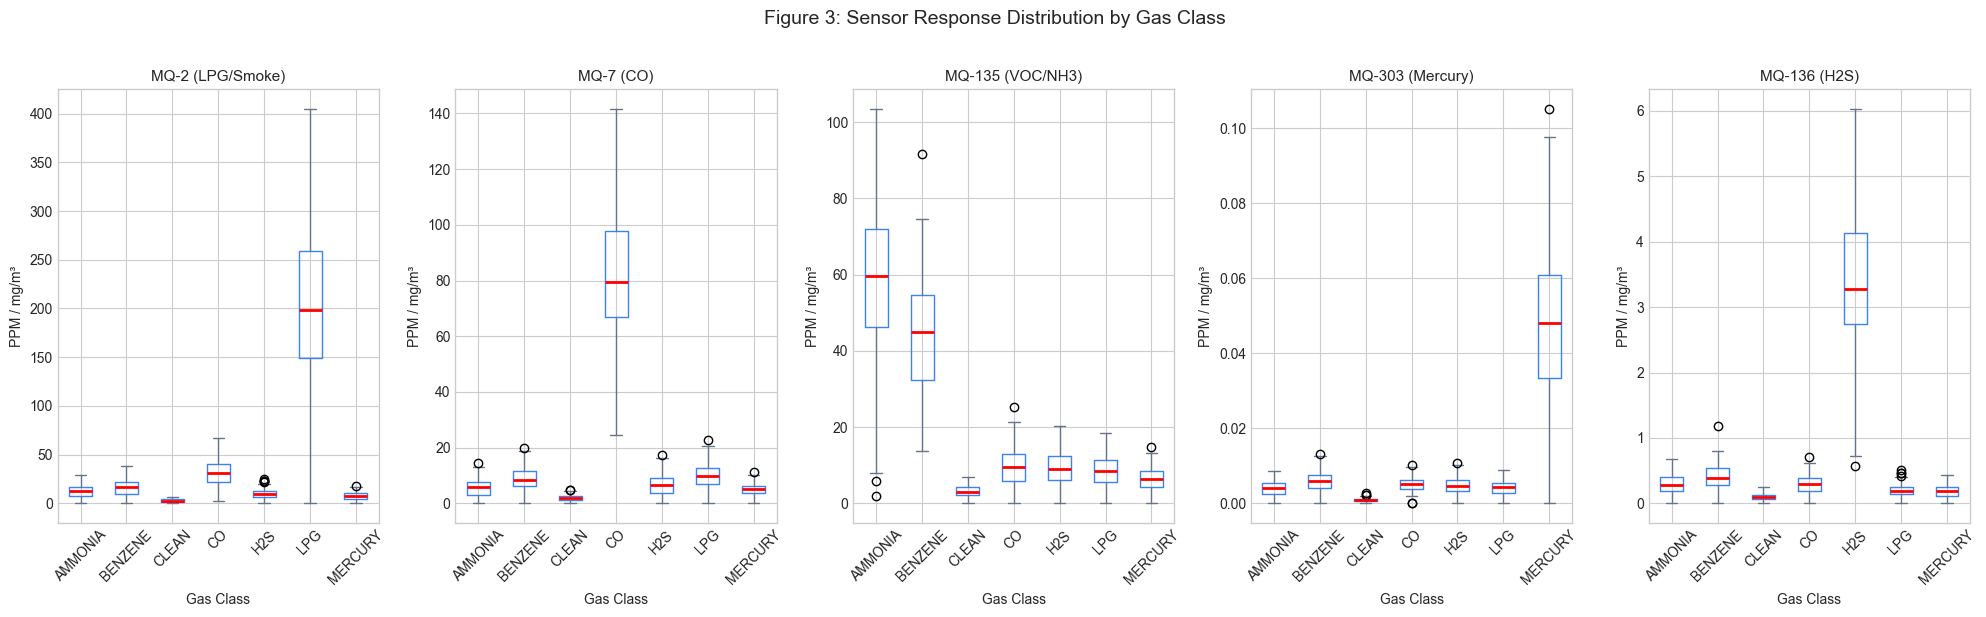

Figure saved ✅


In [9]:
sensor_cols = [c for c in ['mq2_ppm', 'mq7_ppm', 'mq135_ppm', 'mq303_ppm', 'mq136_ppm'] if c in df.columns]

fig, axes = plt.subplots(1, len(sensor_cols), figsize=(20, 6))
if len(sensor_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, sensor_cols):
    df.boxplot(column=col, by=class_col, ax=ax,
               boxprops=dict(color='#3b82f6'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='#64748b'),
               capprops=dict(color='#64748b'))
    ax.set_title(sensor_names.get(col, col), fontsize=11)
    ax.set_xlabel('Gas Class')
    ax.set_ylabel('PPM / mg/m³')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Figure 3: Sensor Response Distribution by Gas Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig3_boxplots_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved ✅')

## 1.7 Correlation Matrix

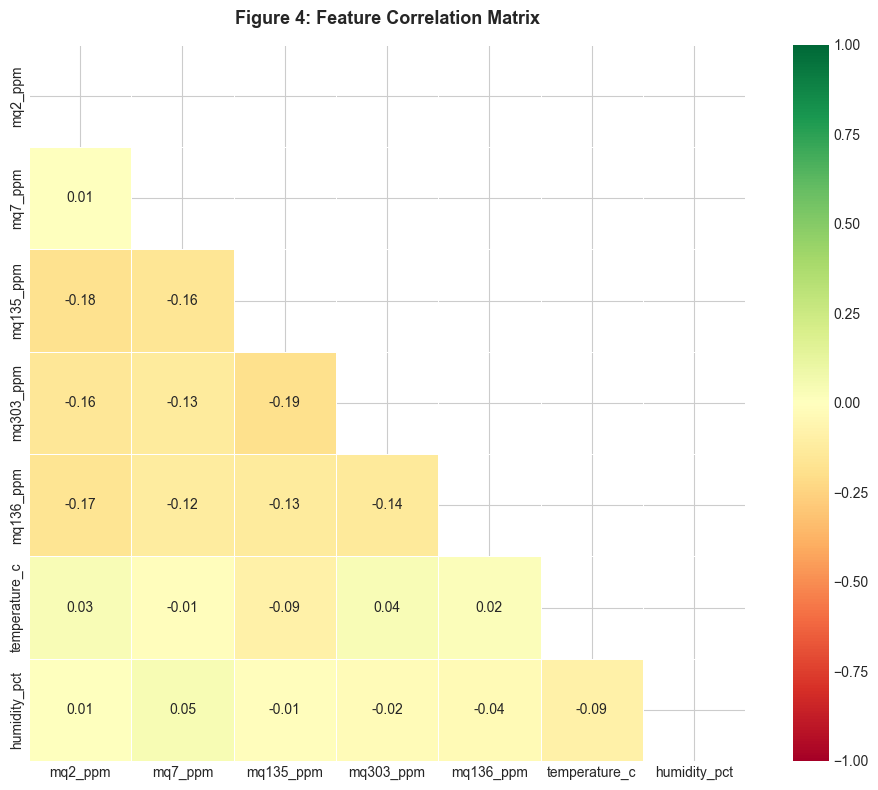

Figure saved ✅

=== HIGH CORRELATIONS (|r| > 0.7) ===
  No high correlations found (good for independence of features)


In [10]:
numeric_df = df[feature_cols]
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            mask=mask,
            square=True, linewidths=0.5,
            ax=ax, annot_kws={'size': 10})
ax.set_title('Figure 4: Feature Correlation Matrix', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(SAVE_DIR / 'fig4_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved ✅')

# High correlations
print('\n=== HIGH CORRELATIONS (|r| > 0.7) ===')
corr_unstacked = corr_matrix.unstack()
high_corr = corr_unstacked[abs(corr_unstacked) > 0.7]
high_corr = high_corr[high_corr.index.get_level_values(0) != high_corr.index.get_level_values(1)]
if len(high_corr) > 0:
    for (a, b), val in high_corr.items():
        if a < b:  # avoid duplicates
            print(f'  {a} ↔ {b}: r = {val:.3f}')
else:
    print('  No high correlations found (good for independence of features)')

## 1.8 Outlier Detection (IQR Method)

In [11]:
print('=== OUTLIER ANALYSIS (IQR Method) ===')
for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    pct = len(outliers) / len(df) * 100
    flag = '⚠' if pct > 5 else '✅'
    print(f'{flag} {col:20s}: {len(outliers):4d} outliers ({pct:.1f}%) | Range: [{lower:.3f}, {upper:.3f}]')

=== OUTLIER ANALYSIS (IQR Method) ===
⚠ mq2_ppm             :  152 outliers (14.5%) | Range: [-25.648, 57.480]
⚠ mq7_ppm             :  150 outliers (14.3%) | Range: [-9.066, 23.749]
⚠ mq135_ppm           :   72 outliers (6.9%) | Range: [-30.878, 64.705]
⚠ mq303_ppm           :  145 outliers (13.8%) | Range: [-0.005, 0.014]
⚠ mq136_ppm           :  147 outliers (14.0%) | Range: [-0.346, 0.941]
✅ temperature_c       :    7 outliers (0.7%) | Range: [20.093, 36.158]
✅ humidity_pct        :   11 outliers (1.0%) | Range: [38.851, 91.207]


## 1.9 Pair Plot (Key Sensors)

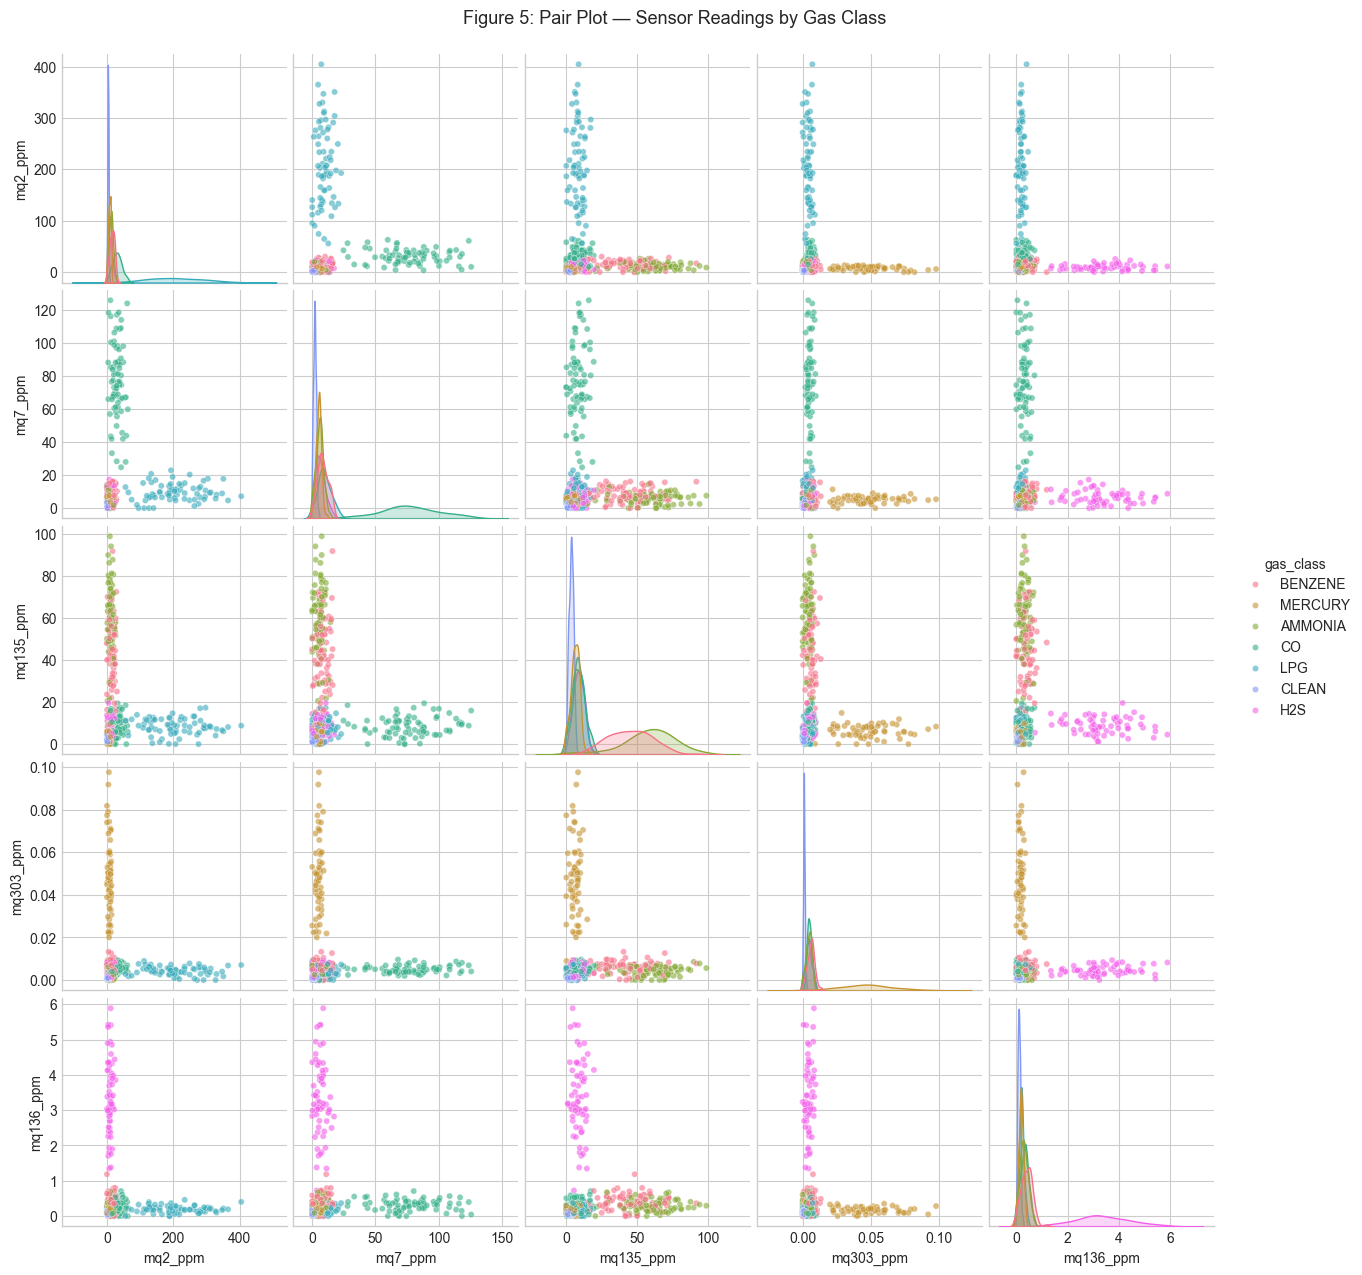

Figure saved ✅


In [12]:
key_sensors = [c for c in ['mq2_ppm', 'mq7_ppm', 'mq135_ppm', 'mq303_ppm', 'mq136_ppm', class_col] if c in df.columns]
sample_df = df[key_sensors].copy()
if len(sample_df) > 500:
    sample_df = sample_df.sample(500, random_state=42)

g = sns.pairplot(sample_df, hue=class_col, diag_kind='kde',
                 plot_kws={'alpha': 0.6, 's': 20},
                 palette='husl')
g.figure.suptitle('Figure 5: Pair Plot — Sensor Readings by Gas Class', y=1.02, fontsize=13)
plt.savefig(SAVE_DIR / 'fig5_pairplot.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved ✅')

## 1.10 EDA Summary

In [13]:
print('=' * 60)
print('EDA SUMMARY')
print('=' * 60)
print(f'Total samples:          {len(df)}')
print(f'Total features:         {len(feature_cols)}')
print(f'Target classes:         {df[class_col].nunique()}')
print(f'Missing values:         {df.isnull().sum().sum()}')
print(f'Duplicate rows:         {df.duplicated().sum()}')
print(f'Class imbalance ratio:  {class_counts.max() / class_counts.min():.2f}x')
print()
print('Actions for preprocessing:')
if df.isnull().sum().sum() > 0:
    print('  → Handle missing values (median imputation)')
if df.duplicated().sum() > 0:
    print('  → Remove duplicate rows')
if class_counts.max() / class_counts.min() > 3:
    print('  → Apply SMOTE for class imbalance')
print('  → Normalize features with MinMaxScaler')
print('  → Train/Test split (80/20, stratified)')
print()
print('✅ Notebook 01 complete — proceed to 02_preprocessing.ipynb')

EDA SUMMARY
Total samples:          1050
Total features:         7
Target classes:         7
Missing values:         0
Duplicate rows:         0
Class imbalance ratio:  1.00x

Actions for preprocessing:
  → Normalize features with MinMaxScaler
  → Train/Test split (80/20, stratified)

✅ Notebook 01 complete — proceed to 02_preprocessing.ipynb
